# Additional tumor samples for external validation of network

We would like to test whether the network (and its attractors) is robust in other datasets, including human tumors. Here, we'll preprocess several different tumor datasets to be processed with `preprocess_adata.py` and used in the BooleaBayes code for validation.

In [1]:
import scvelo as scv
import scanpy as sc
import os.path as op
import os
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import sys
import magic
# import dropkick as dk   # dropkick incompatible with current env; skipped
import cellrank as cr
import scanorama
from py_pcha import PCHA
from sklearn.utils import shuffle
from matplotlib.colors import CenteredNorm


In [2]:
# ── Paths and parameters matching adata_imputed_combined_v3 pipeline ──
DIRECT_NET_INDIR = '../../network-inference-DIRECT-NET/DIRECT-NET-FILES/'
NETWORK_FILE     = 'Direct_net_pval.csv'   # v3: p-value-filtered network

# Extra marker genes added in v3 (same set used for adata_imputed_combined_v3.csv)
EXTRA_GENES_V3 = [
    'CD24A', 'CD44', 'EPCAM', 'ICAM1', 'NCAM1', 'SOX11',
    'HES1',  'NFYC', 'NR6A1', 'RBPJ',  'TFDP1', 'ZBTB18',
]


In [3]:
def preprocess_adata(adata, DIRECT_NET_INDIR,
                      Direct_net_file='Direct_net.csv',
                      outfile_name='adata_imputed.csv',
                      extra_genes=None,
                      imputed_layer='imputed',
                      species='mouse',
                      add_figr=True,
                      out_dir='../../network-inference-DIRECT-NET/data/'):
    """Extract network genes from the MAGIC-imputed layer and save as CSV.
    Mirrors network-inference-DIRECT-NET/preprocess_adata.py, using v3 defaults.
    """
    direct_net = pd.read_csv(os.path.join(DIRECT_NET_INDIR, Direct_net_file),
                             header=0, index_col=0)
    direct_net['Target_gene'] = [i.upper() for i in direct_net['Target_gene']]

    tfs = []
    for _, r in direct_net.iterrows():
        tfs.append(r['TF motif'])
        tfs.append(r['Target_gene'])
    tfs = list(set(tfs))

    if add_figr:
        figr = pd.read_csv(os.path.join(DIRECT_NET_INDIR, 'FigR_DORC_TF.csv'),
                           header=0, index_col=0)
        figr.DORC  = [i.upper() for i in figr.DORC]
        figr.Motif = [i.upper() for i in figr.Motif]
        for _, r in figr.iterrows():
            tfs.append(r['Motif'])
            tfs.append(r['DORC'])

    tfs = list(set(tfs))

    if extra_genes is not None:
        tfs.extend(extra_genes)

    var_upper = [i.upper() for i in adata.var_names]
    overlap   = list(set(tfs).intersection(set(var_upper)))
    missing   = list(set(tfs).difference(set(var_upper)))
    print(f'Genes in network but missing from data ({len(missing)}): {missing}')
    print(f'Genes retained: {len(overlap)}')

    if species == 'mouse':
        adata_net = adata[:, [i.capitalize() for i in overlap]]
    elif species == 'human':
        adata_net = adata[:, [i.upper() for i in overlap]]
    else:
        raise ValueError("species must be 'mouse' or 'human'")

    imputed_df = pd.DataFrame(
        adata_net.layers[imputed_layer],
        index=adata_net.obs_names,
        columns=adata_net.var_names,
    )
    out_path = os.path.join(out_dir, outfile_name)
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    imputed_df.to_csv(out_path)
    print(f'Saved → {out_path}')
    return imputed_df


In [8]:
indir = "../../data/external_validation_looms/allografts"
def read_loom(file, indir, cache=True):
    a = sc.read(op.join(indir, f"{file}.loom"), cache=cache)
    a.var_names_make_unique()
    return a
samples = ['YN1','YN2','YN3','YN5','YN6','YN7','YN8','YN9','YN10','YN11','YN12','YN13']
[a1,a2,a3,a4,a5,a6,a7,a8,a9,a10,a11,a12] = [read_loom(f"possorted_genome_bam_{sample}", indir) for sample in samples]


/Users/smgroves/Documents/anaconda3/envs/mazebox_minimal/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/smgroves/Documents/anaconda3/envs/mazebox_minimal/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/smgroves/Documents/anaconda3/envs/mazebox_minimal/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/smgroves/Documents/anaconda3/envs/mazebox_minimal/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Use

In [9]:
# v3 gene selection: union of TF/target genes from Direct_net_pval.csv + FigR_DORC_TF.csv
# (same logic as preprocess_adata; shown here for reference / QC)
direct_net = pd.read_csv(os.path.join(DIRECT_NET_INDIR, NETWORK_FILE), header=0, index_col=0)
direct_net['Target_gene'] = [i.upper() for i in direct_net['Target_gene']]
figr = pd.read_csv(os.path.join(DIRECT_NET_INDIR, 'FigR_DORC_TF.csv'), header=0, index_col=0)
figr.DORC  = [i.upper() for i in figr.DORC]
figr.Motif = [i.upper() for i in figr.Motif]


In [10]:
network_tfs = list(set(direct_net['TF motif']).union(set(direct_net['Target_gene'])))
figr_genes  = list(set(figr['Motif']).union(set(figr['DORC'])))
retain_genes = list(set(network_tfs + figr_genes + EXTRA_GENES_V3))
print(f'Total network genes (v3): {len(retain_genes)}')


Total network genes (v3): 94


In [11]:
# Concatenate all allograft samples
adata = sc.concat([a1,a2,a3,a4,a5,a6,a7,a8,a9,a10,a11,a12], label='tumor', keys=samples)
adata.var_names_make_unique()

# Basic QC filtering
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
sc.pp.calculate_qc_metrics(adata, inplace=True)

# Normalize and log-transform (mirrors mazebox X_final='log1p_norm')
# Raw counts are preserved before this step
adata.layers['counts'] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
print(adata)


AnnData object with n_obs × n_vars = 36978 × 21127
    obs: 'tumor', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'log1p'
    layers: 'matrix', 'ambiguous', 'spliced', 'unspliced', 'counts'


In [13]:
sc.tl.pca(adata, n_comps=50, use_highly_variable=False)
scv.pp.neighbors(adata, random_state=0)
sc.tl.umap(adata, random_state=0)

/var/folders/vh/xk34gq593k53lzm7wlyg64xw0000gn/T/ipykernel_26682/2355813523.py:2: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  scv.pp.neighbors(adata, random_state=0)


computing neighbors
    finished (0:00:07) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)


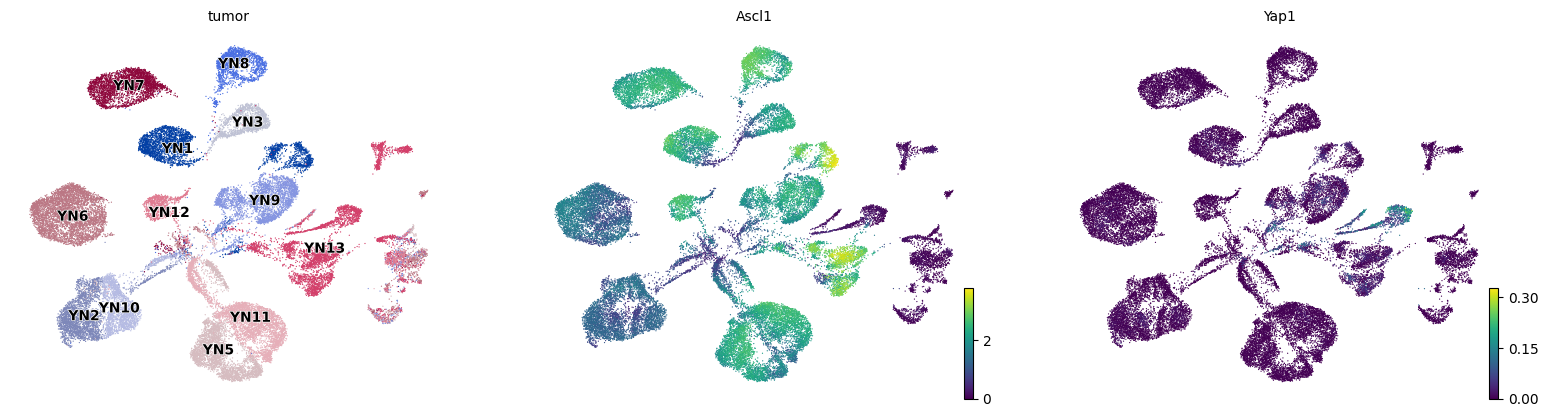

In [14]:
scv.pl.umap(adata, color = ['tumor','Ascl1','Yap1'], smooth = True, legend_loc = 'on data')

In [15]:
therapy_dict = {"Sensitive":['YN4','YN6','YN10','YN12'], 'More resistant':['YN11'], 'Resistant clone' : ['YN2'],
                "Resistant":['YN1','YN3','YN5','YN7','YN8','YN9'], 'TKO':['YN13']}

reverse_dict = {}
for i in therapy_dict.keys():
    for j in therapy_dict[i]:
        reverse_dict[j] = i

adata.obs['response'] = [reverse_dict[i] for i in adata.obs['tumor']]

In [16]:
allograft_id = {"YN1":"mt2", "YN2":"2LR","YN3":"mt3","YN5":"mt4","YN6":"5B","YN7":"mt5","YN8":"3L","YN9":"mt6",
               "YN10":"2L","YN11":"mt4Rf","YN12":"1L","YN13":"TKO-luc"}


adata.obs['allograft'] = [allograft_id[i] for i in adata.obs['tumor']]

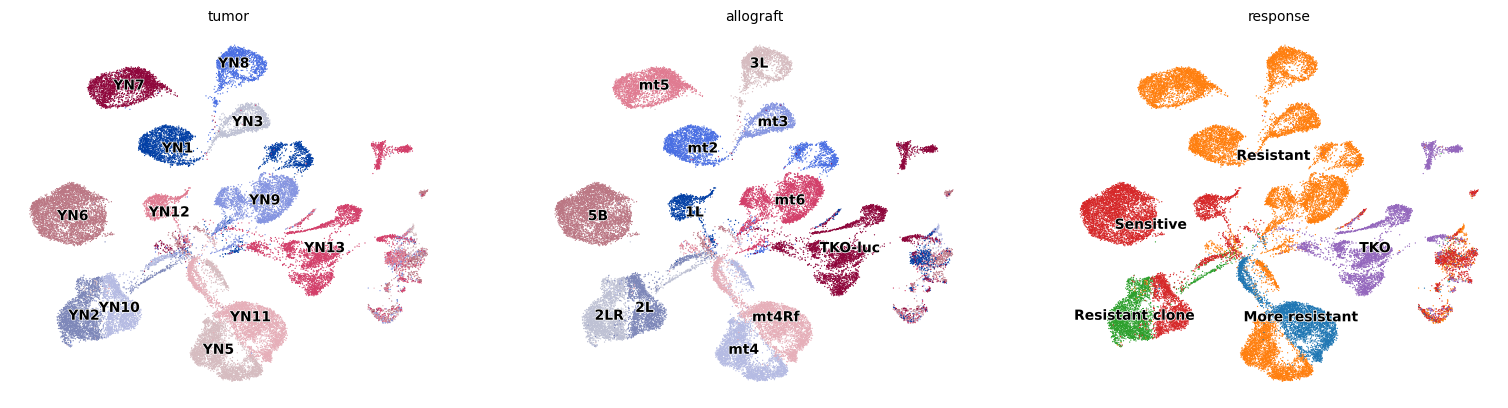

In [17]:
scv.pl.umap(adata, color = ['tumor','allograft','response'], smooth = True, legend_loc = 'on data')

In [18]:
# mb.pp.scanorama_recipe(adata, groups = 'tumor', correct = True, basis = 'umap')


## MAGIC

For stronger PCHA, we'll run MAGIC.

In [19]:
# Run MAGIC imputation on log1p-normalized counts (mirrors combined-dataset pipeline)
# MAGIC denoises and imputes dropout events using a diffusion process over the full gene space.
magic_operator = magic.MAGIC(solver='approximate')
X_magic = magic_operator.fit_transform(adata)


Calculating MAGIC...
  Running MAGIC on 36978 cells and 21127 genes.
  Calculating graph and diffusion operator...
    Calculating PCA...


/Users/smgroves/Documents/anaconda3/envs/mazebox_minimal/lib/python3.9/site-packages/magic/magic.py:650: DeprecationWarning: Call to deprecated method task. (Use TaskLogger.log_task instead) -- Deprecated since version 1.1.0.
  with _logger.task("MAGIC"):
/Users/smgroves/Documents/anaconda3/envs/mazebox_minimal/lib/python3.9/site-packages/magic/magic.py:381: DeprecationWarning: Call to deprecated method info. (Use TaskLogger.log_info instead) -- Deprecated since version 1.1.0.
  _logger.info(
/Users/smgroves/Documents/anaconda3/envs/mazebox_minimal/lib/python3.9/site-packages/magic/magic.py:436: DeprecationWarning: Call to deprecated method task. (Use TaskLogger.log_task instead) -- Deprecated since version 1.1.0.
  with _logger.task("graph and diffusion operator"):


    Calculated PCA in 79.89 seconds.
    Calculating KNN search...
    Calculated KNN search in 3.57 seconds.
    Calculating affinities...
    Calculated affinities in 5.30 seconds.
  Calculated graph and diffusion operator in 88.88 seconds.
  Calculating imputation...


/Users/smgroves/Documents/anaconda3/envs/mazebox_minimal/lib/python3.9/site-packages/magic/magic.py:748: DeprecationWarning: Call to deprecated method task. (Use TaskLogger.log_task instead) -- Deprecated since version 1.1.0.
  with _logger.task("imputation"):


  Calculated imputation in 0.27 seconds.
Calculated MAGIC in 95.25 seconds.


In [20]:
sc.pp.pca(X_magic)

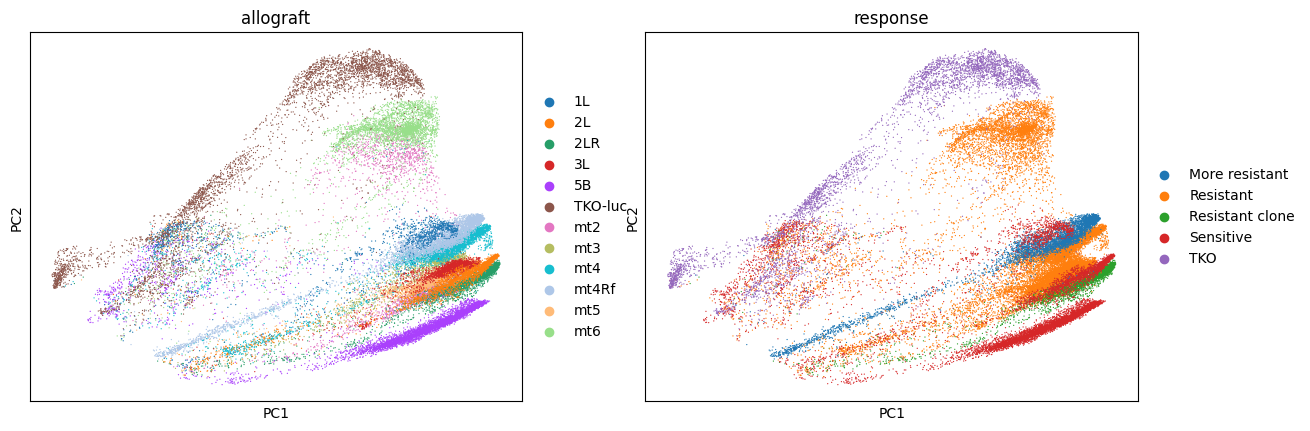

In [21]:
sc.pl.pca(X_magic, color=['allograft','response'])

In [22]:
scv.pp.neighbors(X_magic, random_state=0)
sc.tl.umap(X_magic, random_state=0)

/var/folders/vh/xk34gq593k53lzm7wlyg64xw0000gn/T/ipykernel_26682/2838413404.py:1: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  scv.pp.neighbors(X_magic, random_state=0)


computing neighbors
    finished (0:00:07) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)


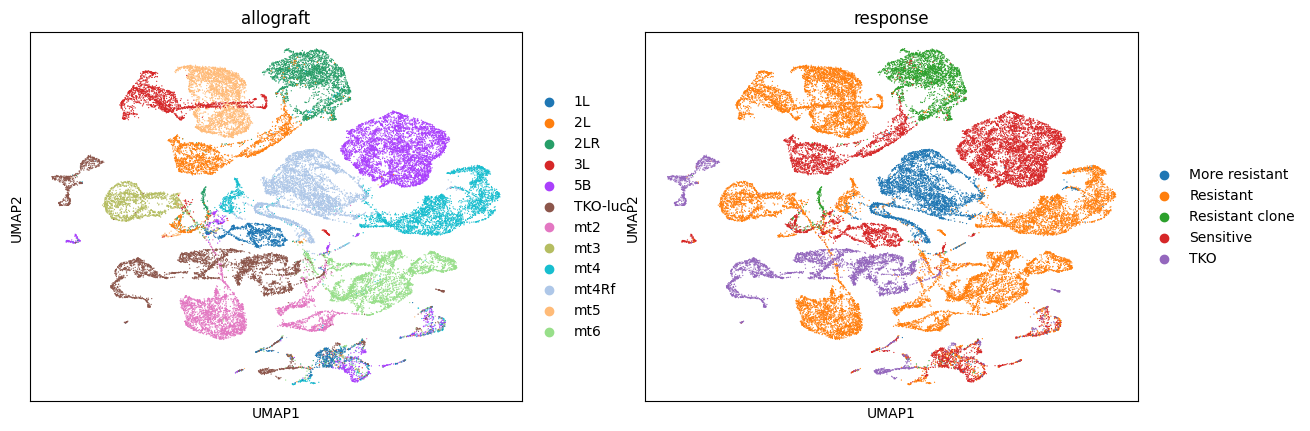

In [23]:
sc.pl.umap(X_magic,color=['allograft','response'])

In [24]:
X_magic

AnnData object with n_obs × n_vars = 36978 × 21127
    obs: 'tumor', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'response', 'allograft'
    var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'pca', 'allograft_colors', 'response_colors', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [25]:
adata.layers['imputed'] = X_magic.X
adata.obsm['X_pca_imputed'] = X_magic.obsm['X_pca']

In [26]:
# ── Extract v3 network genes from MAGIC layer → CSV ──────────────────────
preprocess_adata(
    adata, DIRECT_NET_INDIR,
    Direct_net_file=NETWORK_FILE,
    outfile_name='allografts_imputed_v3.csv',
    extra_genes=EXTRA_GENES_V3,
    imputed_layer='imputed',
    species='mouse',
)


Genes in network but missing from data (1): ['NKX22']
Genes retained: 93
Saved → ../../network-inference-DIRECT-NET/data/allografts_imputed_v3.csv


Gene,Nfix,Tcf7l2,Hif1a,Stat4,Icam1,Elf5,Pknox2,Esr1,Grhl2,Zeb1,...,Six4,Plagl1,Stat1,Tead1,Rorb,Nfatc2,Cux1,Tead4,Nfkb1,Cd44
CellID,,,,,,,,,,,,,,,,,,,,,
possorted_genome_bam_1FL4V:AACCATGGTGCCTGTGx,0.743510,0.007135,0.222842,0.002008,0.004170,-0.000698,0.039475,-0.003221,0.005361,0.212461,...,0.075157,0.002041,0.013700,0.159164,0.106619,0.006096,0.259734,0.000922,0.032642,-0.012917
possorted_genome_bam_1FL4V:AACCGCGAGTCCAGGAx,0.741690,0.003555,0.223644,0.000817,0.004194,0.000120,0.036779,-0.003470,0.007526,0.217364,...,0.078331,0.001482,0.012774,0.180360,0.107515,0.009851,0.247606,0.000788,0.031009,-0.010565
possorted_genome_bam_1FL4V:AAAGCAATCTGCGACGx,0.192146,0.003655,0.313083,0.005995,0.044275,-0.001074,0.050087,0.010882,0.051687,0.070556,...,0.191362,0.004700,0.124442,0.157176,0.222120,0.035116,0.273380,0.000756,0.063098,0.028833
possorted_genome_bam_1FL4V:AAACCTGGTCGCATCGx,0.684849,0.006215,0.259108,0.001878,0.000247,-0.003621,0.050863,0.002396,0.005637,0.228416,...,0.088870,0.000749,0.019275,0.184681,0.126669,0.004958,0.320754,0.000856,0.040254,-0.010324
possorted_genome_bam_1FL4V:AAAGATGGTCAAAGATx,0.313199,0.002194,0.265250,-0.000054,0.026688,-0.000198,0.050897,0.009953,0.043320,0.044202,...,0.188521,0.001315,0.100219,0.175476,0.214216,0.049033,0.278100,0.000899,0.052609,0.009133
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
possorted_genome_bam_0SG90:TTTACTGCATGTCTCCx,-0.082271,0.036397,0.223405,0.000709,0.366943,-0.004485,0.001063,-0.004339,0.000934,0.025409,...,0.034840,-0.002659,0.175966,0.022347,-0.005952,-0.006702,0.010299,0.001842,0.033571,1.129620
possorted_genome_bam_0SG90:TTTCCTCTCCGCATAAx,-0.054053,0.004703,0.151521,0.048013,0.145608,0.010704,0.021005,0.005322,0.033122,0.032255,...,0.192299,0.010303,0.022369,0.014817,0.306321,0.102027,0.155838,0.001110,0.057233,0.169238
possorted_genome_bam_0SG90:TTTACTGCACTCAGGCx,-0.038551,0.034648,0.211431,0.007662,0.394929,-0.002077,-0.006472,0.002091,-0.002174,0.031556,...,0.006917,-0.001606,0.299146,0.001819,-0.008822,-0.007196,0.046603,0.002177,0.108310,1.124505


In [19]:
adata.write_h5ad("../../data/external_validation_looms/allografts.h5ad")

In [21]:
adata.obs['allograft'].to_csv("../../data/external_validation_looms/allograft_clusters.csv")

In [30]:
tko = adata[adata.obs['allograft']=='TKO-luc',:].copy()

tko.write_h5ad("../../data/external_validation_looms/tko_allograftdata.h5ad")

tko.obs['allograft'].to_csv("../../data/external_validation_looms/tko_clusters.csv")

In [31]:
b5 = adata[adata.obs['allograft']=='5B',:].copy()

b5.write_h5ad("../../data/external_validation_looms/5B_allograftdata.h5ad")

b5.obs['allograft'].to_csv("../../data/external_validation_looms/5B_clusters.csv")

In [27]:
for allo in adata.obs.allograft.cat.categories:
    print(allo)
    tmp = adata[adata.obs['allograft']==allo,:].copy()

    tmp.write_h5ad(f"../../data/external_validation_looms/{allo}_allograftdata.h5ad")

    tmp.obs['allograft'].to_csv(f"../../data/external_validation_looms/{allo}_clusters.csv")

1L
2L
2LR
3L
5B
TKO-luc
mt2
mt3
mt4
mt4Rf
mt5
mt6


In [28]:
# ── Per-allograft: extract v3 network genes → CSV ────────────────────────
for allo in adata.obs.allograft.cat.categories:
    tmp = sc.read_h5ad(f'../../data/external_validation_looms/{allo}_allograftdata.h5ad')
    preprocess_adata(
        tmp, DIRECT_NET_INDIR,
        Direct_net_file=NETWORK_FILE,
        outfile_name=f'adata_{allo}_allografts_v3.csv',
        extra_genes=EXTRA_GENES_V3,
        imputed_layer='imputed',
        species='mouse',
    )


Genes in network but missing from data (1): ['NKX22']
Genes retained: 93
Saved → ../../network-inference-DIRECT-NET/data/adata_1L_allografts_v3.csv
Genes in network but missing from data (1): ['NKX22']
Genes retained: 93
Saved → ../../network-inference-DIRECT-NET/data/adata_2L_allografts_v3.csv
Genes in network but missing from data (1): ['NKX22']
Genes retained: 93
Saved → ../../network-inference-DIRECT-NET/data/adata_2LR_allografts_v3.csv
Genes in network but missing from data (1): ['NKX22']
Genes retained: 93
Saved → ../../network-inference-DIRECT-NET/data/adata_3L_allografts_v3.csv
Genes in network but missing from data (1): ['NKX22']
Genes retained: 93
Saved → ../../network-inference-DIRECT-NET/data/adata_5B_allografts_v3.csv
Genes in network but missing from data (1): ['NKX22']
Genes retained: 93
Saved → ../../network-inference-DIRECT-NET/data/adata_TKO-luc_allografts_v3.csv
Genes in network but missing from data (1): ['NKX22']
Genes retained: 93
Saved → ../../network-inference-D

In [30]:
#combine RORA and RORB into RORA_RORB, change all genes to uppercase, and save as new csvs
allo_dir ="/Users/smgroves/Documents/GitHub/multiome-analysis/network-inference-DIRECT-NET/data/allografts"
for allo in adata.obs.allograft.cat.categories:
    tmp = pd.read_csv(f"{allo_dir}/adata_{allo}_allografts_v3.csv", index_col=0, header=0)

    RORA_RORB_ave = tmp[["Rora", "Rorb"]].mean(axis=1)

    tmp["RORA_RORB"] = RORA_RORB_ave
    tmp.to_csv(f"{allo_dir}/adata_{allo}_allografts_v3_RORA_RORB_ave.csv")

# Human tumors from MSK

In [34]:
human = sc.read_h5ad("../../data/external_validation_looms/adata.SCLC.010920.h5ad")
human

AnnData object with n_obs × n_vars = 54313 × 22216
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'mito_frac', 'RBP_frac', 'batch', 'patient', 'tissue', 'treatment', 'procedure', 'SCLC_subtype', 'SCLC_subtype_plus_TP53_RB1_wt', 'pval_SCLC-A', 'pval_SCLC-N', 'pval_SCLC-P', 'NEUROD genes', 'MHCI_PRESENTATION', 'MHCII_PRESENTATION', 'SCLC_major_subtype_of_sample', 'clusters', 'treatment_categorized', 'recurrent_cluster', 'histo', 'clusters_fine'
    var: 'knnDREMI|PLCG2', 'PLCG2_modules', 'AXONOGENESIS', 'NEURON_DIFFERENTIATION', 'NEUROPEPTIDE_RECEPTOR', 'EMT'
    uns: 'diffmap_evals', 'neighbors', 'num_components', 'paga', 'umap', 'var_explained'
    obsm: 'X_diffmap', 'X_pca', 'X_umap'
    layers: 'imputed_normalized', 'log2(X+0.1)', 'normalized'
    obsp: 'connectivities', 'distances'

In [ ]:
# ── MAGIC imputation for human tumors ────────────────────────────────────
# Normalize if not already done (check for raw counts)
if 'imputed_normalized' not in human.layers:
    print('Running normalization + MAGIC on human tumor data...')
    human.layers['counts'] = human.X.copy()
    sc.pp.normalize_total(human, target_sum=1e4)
    sc.pp.log1p(human)
    magic_op_human = magic.MAGIC(solver='approximate')
    X_magic_human  = magic_op_human.fit_transform(human)
    human.layers['imputed_normalized'] = X_magic_human.X
    print('MAGIC done; layer stored as imputed_normalized')
else:
    print('imputed_normalized layer already present — skipping MAGIC')


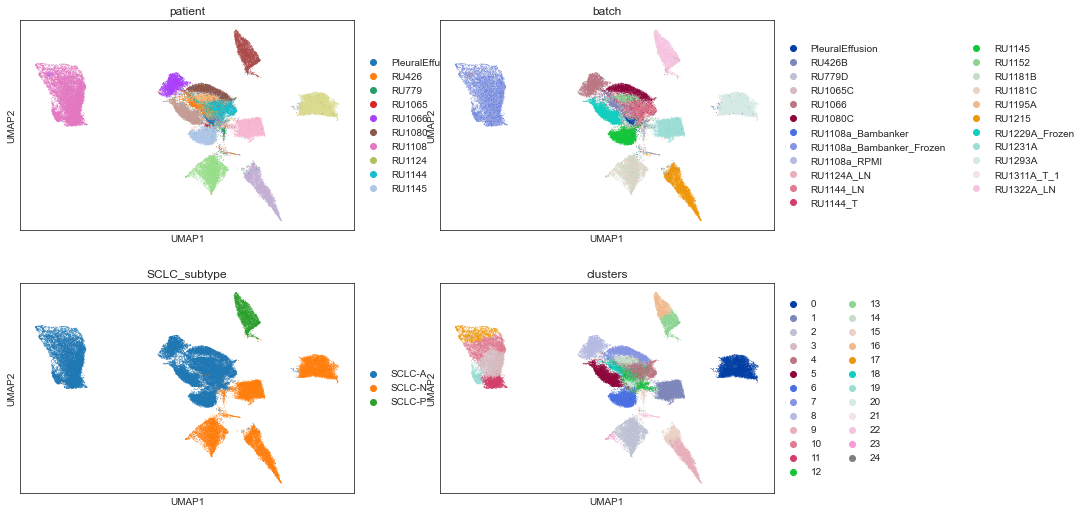

In [47]:
sc.pl.umap(human, color = ['patient','batch','SCLC_subtype', 'clusters'], ncols = 2)

In [43]:
human.obs['patient'].to_csv("../../data/external_validation_looms/human_tumors_MSK_clusters.csv")

In [48]:
for tumor in human.obs.patient.cat.categories:
    print(tumor)
    tmp = human[human.obs['patient']==tumor,:].copy()

    tmp.write_h5ad(f"../../data/external_validation_looms/human_tumors/{tumor}_human_tumor_data.h5ad")

    tmp.obs['clusters'].to_csv(f"../../network-inference-DIRECT-NET/data/human_tumors/{tumor}_clusters.csv")

PleuralEffusion
RU426
RU779
RU1065
RU1066
RU1080
RU1108
RU1124
RU1144
RU1145
RU1152
RU1181
RU1195
RU1215
RU1229
RU1231
RU1293
RU1311
RU1322


In [ ]:
# ── Human MSK cohort: extract v3 network genes → CSV ─────────────────────
preprocess_adata(
    human, DIRECT_NET_INDIR,
    Direct_net_file=NETWORK_FILE,
    outfile_name='human_tumors/adata_human_tumors_MSK_v3.csv',
    extra_genes=EXTRA_GENES_V3,
    imputed_layer='imputed_normalized',
    species='human',
)


In [ ]:
# ── Per-tumor: re-split with MAGIC layer and extract v3 network genes ─────
for tumor in human.obs.patient.cat.categories:
    tmp = human[human.obs['patient'] == tumor, :].copy()
    # Save updated h5ad (now includes imputed_normalized layer)
    tmp.write_h5ad(f'../../data/external_validation_looms/human_tumors/{tumor}_human_tumor_data.h5ad')
    # Extract network genes and save CSV
    preprocess_adata(
        tmp, DIRECT_NET_INDIR,
        Direct_net_file=NETWORK_FILE,
        outfile_name=f'human_tumors/adata_{tumor}_v3.csv',
        extra_genes=EXTRA_GENES_V3,
        imputed_layer='imputed_normalized',
        species='human',
    )
